In [1]:
%load_ext autoreload
%autoreload 2
%cd ../..

/home/philippe/MolGenDocking


In [4]:
from pathlib import Path
import json
import re

import pandas as pd
import numpy as np
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
import os
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import DataStructs

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import roc_curve, roc_auc_score
from notebooks.utils import PandasTableFormatter
from molrgen.evaluation.diversity_aware_top_k import diversity_aware_top_k
from notebooks.utils import *
from molrgen.data.pydantic_dataset import read_jsonl
import jsonlines
from tqdm.auto import tqdm

tqdm.pandas()

FIG_PATH = "MolGenDocking-latex/Figures/Others"
os.makedirs(FIG_PATH, exist_ok=True)


In [46]:
from notebooks.utils.parse_training_curves import load_training_curves
from pathlib import Path
import pandas as pd

# Check on all csv
DIR = Path("notebooks/others")
dfs=[]
for file in DIR.glob("*.csv"):
    dfs.append(load_training_curves(file))

df = pd.concat(dfs).reset_index(drop=True)
df = df.pivot_table(index=["group_size", "step"], columns=["metric"], values="value").reset_index()

In [47]:
df.columns.unique()

Index(['group_size', 'step',
       '02_processed.shuffle_x1.jsonl/reward/correctness',
       '02_processed.shuffle_x1.jsonl/reward/correctness__MAX',
       '02_processed.shuffle_x1.jsonl/reward/correctness__MIN',
       '14_processed.shuffle_x1.jsonl/reward/correctness',
       '14_processed.shuffle_x1.jsonl/reward/correctness__MAX',
       '14_processed.shuffle_x1.jsonl/reward/correctness__MIN',
       'train/online/generations/group/all/reward/correctness',
       'train/online/generations/group/all/reward/correctness__MAX',
       'train/online/generations/group/all/reward/correctness__MIN',
       'train/rl_loss/entropy', 'train/rl_loss/entropy__MAX',
       'train/rl_loss/entropy__MIN', 'train/rl_loss/n_tokens',
       'train/rl_loss/n_tokens__MAX', 'train/rl_loss/n_tokens__MIN',
       'train/rl_loss/n_tokens_std', 'train/rl_loss/n_tokens_std__MAX',
       'train/rl_loss/n_tokens_std__MIN', 'train/tokens_seen',
       'train/tokens_seen__MAX', 'train/tokens_seen__MIN'],
      

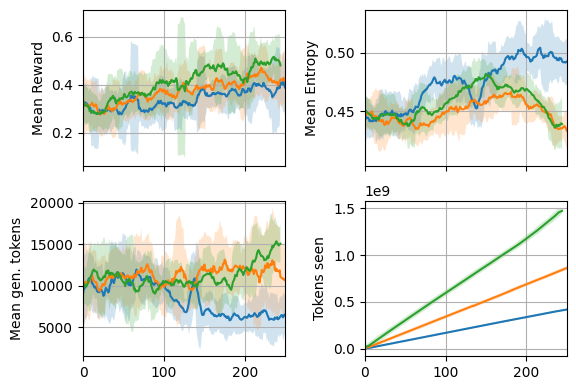

In [96]:


def plot_curve(y:str, ytitle:str, ax:plt.axes):
    for group_size in df_smooth["group_size"].unique():
        mask = df_smooth["group_size"] == group_size
        data = df_smooth[mask].sort_values("step")
        ax.plot(data["step"], data[y + "_ma"], label=f"group_size={group_size}")
        ax.fill_between(
            data["step"],
            data[y + "_ma"] - 2*data[y + "_std"],
            data[y + "_ma"] + 2*data[y + "_std"],
            alpha=0.2
        )

    ax.set_ylabel(ytitle)

# Calculate moving averages and standard deviations
COLS_TO_PLOT = {
    "train/online/generations/group/all/reward/correctness": "Mean Reward",
    "train/rl_loss/entropy": "Mean Entropy",
    "train/rl_loss/n_tokens": "Mean gen. tokens",
    "train/tokens_seen": "Tokens seen",
}

window_size = 10

df_smooth = df.copy()
for col in COLS_TO_PLOT:
    df_smooth[f"{col}_ma"] = df.groupby("group_size")[col].transform(lambda x: x.rolling(window=window_size, center=True, min_periods=3).mean())
    df_smooth[f"{col}_std"] = df.groupby("group_size")[col].transform(lambda x: x.rolling(window=window_size, center=True, min_periods=3).std())

fig, axes = plt.subplots(2, len(COLS_TO_PLOT) // 2, figsize=(6, 4), sharex=True)
axes = axes.flatten()

for i, (col, colname) in enumerate(COLS_TO_PLOT.items()):
    plot_curve(col, colname, axes[i])
    axes[i].set_xlim(0,250)
    axes[i].grid()
fig.tight_layout()
fig.savefig(f"{FIG_PATH}/training_curves.pdf", bbox_inches='tight')